<a href="https://colab.research.google.com/github/TunggTungg/AI_EXERCISEs/blob/main/Kiem_Tra_Giua_K%E1%BB%B3_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Conv2D, MaxPooling2D, Flatten, BatchNormalization, MaxPool2D
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler
from keras.utils import np_utils
from sklearn.utils import shuffle
from keras.datasets import mnist, fashion_mnist, cifar100
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pickle
import tensorflow as tf
import math as m
from keras.utils.np_utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import Callback, EarlyStopping, LearningRateScheduler
from sklearn.model_selection import train_test_split

In [17]:
def plot_history(history_fine):
  f1 = history_fine.history['acc']

  loss = history_fine.history['loss']

  plt.figure(figsize=(8, 8))
  plt.subplot(2, 1, 1)
  plt.plot(f1, label='Acc')
  plt.legend(loc='lower right')
  plt.title('Accuracy')

  plt.subplot(2, 1, 2)
  plt.plot(loss, label='Loss')
  plt.legend(loc='upper right')
  plt.title('Loss')
  plt.xlabel('epoch')
  plt.show()


In [3]:
labels = ['anger', 'happiness', 'sadness', 'surprise']

In [13]:
# Load Data 
with open('data_faces.pickle', 'rb') as f:
    (x, y) = pickle.load(f)

# Preprocessing Datas
x = x.astype('float32')
x /= 255

# Encoding Y
y = np_utils.to_categorical(y)

# Split Data
# x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=42)

# Print Shape 
print(x_train.shape)
# print(x_test.shape)
print(y_train.shape)
# print(y_test.shape)

(313, 224, 224)
(313, 4)


In [19]:
model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same', input_shape = (224,224,1)))
model.add(Conv2D(32, (3,3), activation='relu',kernel_initializer='he_uniform', padding ='same'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
model.add(Dense(4, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer =Adam(), metrics=['acc'])

history = model.fit(x_train, y_train, batch_size = 4, epochs = 10)

Epoch 1/10
79/79 [==============================] - 6s 64ms/step - loss: 7.9773 - acc: 0.2524
Epoch 2/10
79/79 [==============================] - 5s 62ms/step - loss: 0.7936 - acc: 0.7220
Epoch 3/10
79/79 [==============================] - 5s 62ms/step - loss: 0.2723 - acc: 0.9329
Epoch 4/10
79/79 [==============================] - 5s 63ms/step - loss: 0.0553 - acc: 0.9968
Epoch 5/10
79/79 [==============================] - 5s 63ms/step - loss: 0.0579 - acc: 0.9936
Epoch 6/10
79/79 [==============================] - 5s 63ms/step - loss: 0.0289 - acc: 0.9968
Epoch 7/10
79/79 [==============================] - 5s 63ms/step - loss: 0.0158 - acc: 0.9968
Epoch 8/10
79/79 [==============================] - 5s 63ms/step - loss: 0.0423 - acc: 0.9936
Epoch 9/10
79/79 [==============================] - 5s 63ms/step - loss: 0.0123 - acc: 0.9936
Epoch 10/10
79/79 [==============================] - 5s 63ms/step - loss: 0.0170 - acc: 0.9968


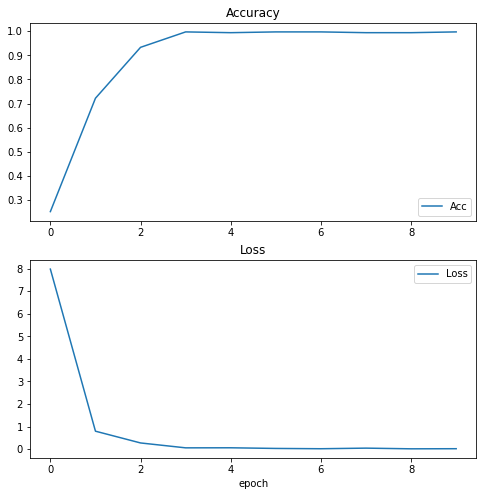

In [20]:
plot_history(history)

Text(0.5, 1.0, 'Model dự đoán là: sadness')

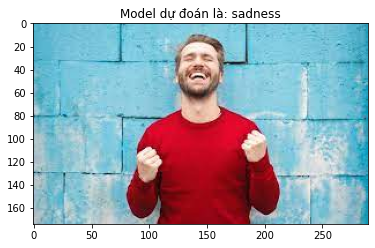

In [25]:
filename = "/content/test_img.jpg"
plt.imshow(cv2.cvtColor(cv2.imread(filename), cv2.COLOR_BGR2RGB), cmap=plt.get_cmap('gray'))
img = cv2.resize(cv2.imread(filename,0), (224,224))
plt.title("Model dự đoán là: " + labels[np.argmax(model.predict(img.reshape(1,224,224)))])

Text(0.5, 1.0, 'Model dự đoán là: anger')

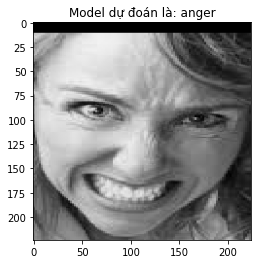

In [27]:
filename = "/content/2Q__ (3)_face.png"
plt.imshow(cv2.cvtColor(cv2.imread(filename), cv2.COLOR_BGR2RGB), cmap=plt.get_cmap('gray'))
img = cv2.resize(cv2.imread(filename,0), (224,224))
plt.title("Model dự đoán là: " + labels[np.argmax(model.predict(img.reshape(1,224,224)))])

Text(0.5, 1.0, 'Model dự đoán là: sadness')

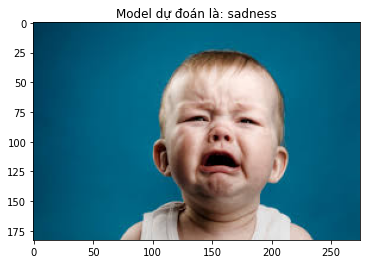

In [21]:
filename = "/content/test2.jpg"
plt.imshow(cv2.cvtColor(cv2.imread(filename), cv2.COLOR_BGR2RGB), cmap=plt.get_cmap('gray'))
img = cv2.resize(cv2.imread(filename,0), (224,224))
plt.title("Model dự đoán là: " + labels[np.argmax(model.predict(img.reshape(1,224,224)))])